# Task 1 -> Single Feature

### 1)Data Retreival and Collection

In [60]:
# Import Libraries
import pandas as pd
import numpy as np

In [61]:
#Load the heart disease dataset
df = pd.read_csv('heart.csv')

In [62]:
#View the data
print('Shape:', df.shape)
df.head(10)# displays first 10 rows

Shape: (270, 14)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [63]:
#Check data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [64]:
#Summary of dataset
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


### 2) Data Cleaning

In [65]:
#Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [66]:
#since there are no missing values, we can proceed with the analysis
#Check target variable if it's binary
print("\nUnique values in Heart Disease:")
print(df['Heart Disease'].unique())


Unique values in Heart Disease:
<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str


In [67]:
#Since there are presence and absence which arent 0 or 1 so we convert them
df['Heart Disease'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})
#Check if they have been mapped properly
print(df['Heart Disease'].unique())

[1 0]


In [68]:
#Check data types
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                int64
dtype: object


In [69]:
#Verify data types are correct
print("\nData type verification:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"⚠️ {col} is object type - may need conversion")
    else:
        print(f"✓ {col} is {df[col].dtype}")


Data type verification:
✓ Age is int64
✓ Sex is int64
✓ Chest pain type is int64
✓ BP is int64
✓ Cholesterol is int64
✓ FBS over 120 is int64
✓ EKG results is int64
✓ Max HR is int64
✓ Exercise angina is int64
✓ ST depression is float64
✓ Slope of ST is int64
✓ Number of vessels fluro is int64
✓ Thallium is int64
✓ Heart Disease is int64


### 3) Feature Design (cholestrol as input feature)

In [70]:
# Handle invalid Cholesterol values (0 → replace with median)
median_chol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)
# Drop any remaining null rows
df.dropna(inplace=True)
print('Cholesterol min after cleaning:', df['Cholesterol'].min())

Cholesterol min after cleaning: 126


In [71]:
#Separate cholestrol(x) and heart disease(y)
x = df[['Cholesterol']]
y = df['Heart Disease']

In [72]:
#Verify the shapes
print("\nFeature matrix shape (x):", x.shape)
print("Target vector shape (y):", y.shape)
print("\nFirst 10 rows of x(cholesterol):")
print(x.head(10))
print("\nFirst 10 values of y(target):")
print(y.head(10))


Feature matrix shape (x): (270, 1)
Target vector shape (y): (270,)

First 10 rows of x(cholesterol):
   Cholesterol
0          322
1          564
2          261
3          263
4          269
5          177
6          256
7          239
8          293
9          407

First 10 values of y(target):
0    1
1    0
2    1
3    0
4    0
5    0
6    1
7    1
8    1
9    1
Name: Heart Disease, dtype: int64


##### Why Cholesterol may be a predictor? 
###### High cholesterol leads to plaque buildup in arteries, increasing the risk of cardiovascular disease. It is a well-known clinical predictorof heart disease, making it a reasonable single feature for an initial model.

Text(0.5, 1.0, 'Cholesterol Distribution by Heart Disease Status')

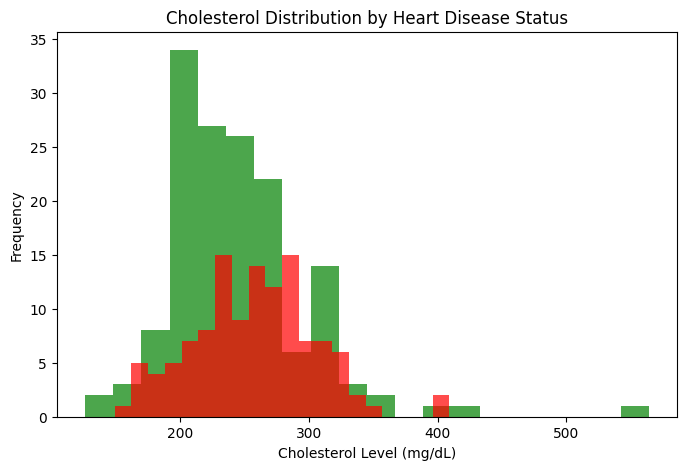

In [73]:
#Quick visualization to support the explanation (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df[df['Heart Disease']==0]['Cholesterol'], bins=20, alpha=0.7, label='No Disease (0)', color='green')
plt.hist(df[df['Heart Disease']==1]['Cholesterol'], bins=20, alpha=0.7, label='Disease (1)', color='red')
plt.xlabel('Cholesterol Level (mg/dL)')
plt.ylabel('Frequency')
plt.title('Cholesterol Distribution by Heart Disease Status')

### 4) Algorithm Selection

##### Why Logistic Regression is suitable for binary classification?

###### The target variable is binary (0 or 1), making this a binary classification problem.
###### Logistic Regression outputs a probability between 0 and 1 using the sigmoid function: σ(z) = 1 / (1 + e^(-z))
###### It is interpretable — the coefficients directly indicate feature influence.
###### It is computationally efficient and works well as a baseline model.

### 5) Loss Function Selection

Binary Cross-Entropy (Log Loss):

Loss = -[y·log(ŷ) + (1-y)·log(1-ŷ)]

When the true label y=1 and the model predicts ŷ close to 1, the loss is near 0.
When the model makes a confident wrong prediction, the loss is very high (penalizes overconfident errors).
This is the standard loss for logistic regression and is minimized during training using gradient descent.

### 6) Model Learning and Training

In [74]:
# Train-test split (80/20)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print('Training samples:', x_train.shape[0])
print(type(x_train))
print(x_train.shape)
print('Testing samples:', x_test.shape[0])


Training samples: 216
<class 'pandas.DataFrame'>
(216, 1)
Testing samples: 54


In [75]:
# Feature scaling (important for gradient-based optimization)
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
x_train_scaled = scaler1.fit_transform(x_train)
x_test_scaled  = scaler1.transform(x_test)

In [76]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(x_train_scaled, y_train)
print('\nModel Coefficient (Cholesterol):', model.coef_[0][0])
print('Model Intercept:', model.intercept_[0])


Model Coefficient (Cholesterol): 0.17648960959078797
Model Intercept: -0.22422750268450287


##### How parameters are learned: 
###### Logistic Regression uses gradient descent (or its variants) to minimize the binary cross-entropy loss. The algorithm iteratively adjusts the weight (coefficient) and bias (intercept) so that the predicted probabilities match the true labels as closely as possible.

### 7) Model Evaluation

In [77]:
#Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [78]:
# Predict classes (0 or 1)
y_pred = model.predict(x_test_scaled)
# Predict probabilities
y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]

print(f"Test set predictions completed!")
print(f"First 10 actual values: {y_test[:10].tolist()}")
print(f"First 10 predictions:   {y_pred[:10].tolist()}")
print(f"First 10 probabilities: {[f'{p:.3f}' for p in y_pred_proba[:10]]}")

Test set predictions completed!
First 10 actual values: [0, 0, 0, 1, 0, 0, 0, 1, 1, 1]
First 10 predictions:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 probabilities: ['0.446', '0.425', '0.456', '0.429', '0.455', '0.414', '0.387', '0.468', '0.432', '0.493']


In [79]:
#Calculate evaluation metrics
print("MODEL EVALUATION METRICS")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n1. ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("   → Overall correctness of the model")
print(f"   → Correct predictions: {accuracy*len(y_test):.0f} out of {len(y_test)}")



MODEL EVALUATION METRICS

1. ACCURACY: 0.5741 (57.41%)
   → Overall correctness of the model
   → Correct predictions: 31 out of 54


In [80]:
# Precision
precision = precision_score(y_test, y_pred)
print(f"\n2. PRECISION: {precision:.4f} ({precision*100:.2f}%)")
print("   → Of all patients predicted to have heart disease, how many actually had it?")
print("   → Formula: TP / (TP + FP)")


2. PRECISION: 0.5714 (57.14%)
   → Of all patients predicted to have heart disease, how many actually had it?
   → Formula: TP / (TP + FP)


In [81]:
# Recall
recall = recall_score(y_test, y_pred)
print(f"\n3. RECALL: {recall:.4f} ({recall*100:.2f}%)")
print("   → Of all patients who actually had heart disease, how many did we catch?")
print("   → Formula: TP / (TP + FN)")


3. RECALL: 0.1667 (16.67%)
   → Of all patients who actually had heart disease, how many did we catch?
   → Formula: TP / (TP + FN)


In [82]:
# F1-Score
f1 = f1_score(y_test, y_pred)
print(f"\n4. F1-SCORE: {f1:.4f} ({f1*100:.2f}%)")
print("   → Harmonic mean of Precision and Recall")
print("   → Formula: 2 × (Precision × Recall) / (Precision + Recall)")


4. F1-SCORE: 0.2581 (25.81%)
   → Harmonic mean of Precision and Recall
   → Formula: 2 × (Precision × Recall) / (Precision + Recall)


In [83]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix (values):")
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (TN): {cm[0,0]} → Correctly predicted NO disease")
print(f"  False Positives (FP): {cm[0,1]} → Incorrectly predicted disease (Type I error)")
print(f"  False Negatives (FN): {cm[1,0]} → Missed disease cases (Type II error)")
print(f"  True Positives (TP): {cm[1,1]} → Correctly predicted disease")


Confusion Matrix (values):
[[27  3]
 [20  4]]

Interpretation:
  True Negatives (TN): 27 → Correctly predicted NO disease
  False Positives (FP): 3 → Incorrectly predicted disease (Type I error)
  False Negatives (FN): 20 → Missed disease cases (Type II error)
  True Positives (TP): 4 → Correctly predicted disease


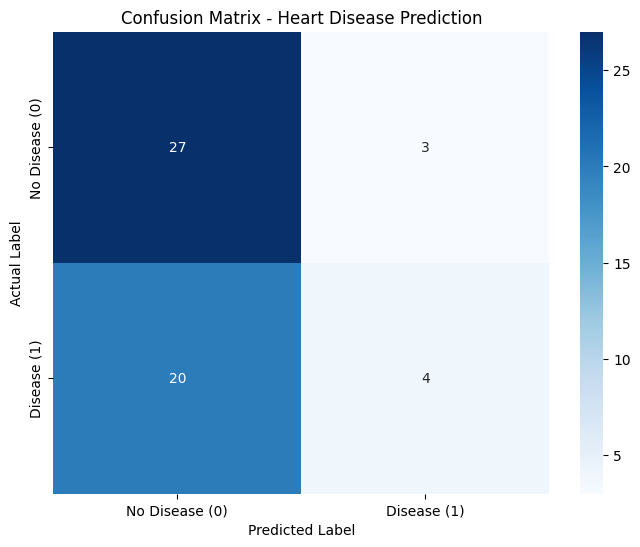

In [84]:
# Visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# TASK 2 -> Multiple Features 

### 1)Data Retrieval and Collection

In [85]:
#Load the heart disease dataset
df = pd.read_csv('heart.csv')

In [86]:
# Reload fresh copy (already cleaned above — reuse df)
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### 2) Data Cleaning

In [87]:
# Already cleaned in Task 1 (missing values handled, cholesterol zeros replaced)
print('Missing values:', df.isnull().sum().sum())
print('Target distribution:\n', df['Heart Disease'].value_counts())

Missing values: 0
Target distribution:
 Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


In [88]:
# Separate features and target for cleaning
X_full = df.drop('Heart Disease', axis=1)
y_full = df['Heart Disease']

### 3) Feature Design

In [89]:
print("Features before encoding:")
print(X_full.dtypes)

Features before encoding:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object


In [90]:
# Identify categorical columns
cat_cols = X_full.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_cols)

Categorical columns: []


In [91]:
# Encode categorical variables using Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    X_full[col] = le.fit_transform(X_full[col])

print('\nFeature types after encoding:')
print(X_full.dtypes)
print('\nFeature shape:', X_full.shape)


Feature types after encoding:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

Feature shape: (270, 13)


##### Why multiple features? 
###### Using all available features captures more variance in the data. Features like age, resting blood pressure, max heart rate, exercise-induced angina, etc. each contribute independent predictive information that cholesterol alone cannot capture.

### 4) Algorithm Selection

##### Same as Task 1 — Logistic Regression with multiple features (multivariate). The model now learns one weight per feature, forming a decision boundary in higher-dimensional space.

### 5) Loss Function Selection

##### Binary Cross-Entropy (Log Loss) — same as Task 1. The loss now accounts for contributions from all features through the combined linear combination z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b.

### 6) Model Learning and Training

In [92]:
# Train-test split
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
# Feature scaling
scaler2 = StandardScaler()
X_full_train_scaled = scaler2.fit_transform(X_full_train)
X_full_test_scaled  = scaler2.transform(X_full_test)


In [93]:
# Train Logistic Regression
model_full = LogisticRegression(max_iter=1000, random_state=42)
model_full.fit(X_full_train_scaled, y_full_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [94]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': model_full.coef_[0]
}).sort_values('Coefficient', ascending=False)
print('Feature Coefficients:')
print(coef_df.to_string(index=False))

Feature Coefficients:
                Feature  Coefficient
Number of vessels fluro     1.185769
                    Sex     0.892690
        Chest pain type     0.716115
               Thallium     0.584150
        Exercise angina     0.481365
            Slope of ST     0.413009
                     BP     0.408808
            Cholesterol     0.341274
          ST depression     0.240702
            EKG results     0.073109
                    Age     0.025068
           FBS over 120    -0.347914
                 Max HR    -0.399470


### 7)Model Evaluation

In [107]:
# Make predictions
y_full_pred = model_full.predict(X_full_test)
y_full_proba = model_full.predict_proba(X_full_test)[:, 1]

c:\Users\SHARMA\OneDrive\Documents\folder\AI\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\SHARMA\OneDrive\Documents\folder\AI\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [109]:
# Metrics
acc_full = accuracy_score(y_full_test, y_full_pred)
prec_full = precision_score(y_full_test, y_full_pred)
rec_full  = recall_score(y_full_test, y_full_pred)
f1_full   = f1_score(y_full_test, y_full_pred)

print('=== Task 2 Evaluation (Multiple Features) ===')
print(f'Accuracy : {acc_full:.4f}')
print(f'Precision: {prec_full:.4f}')
print(f'Recall   : {rec_full:.4f}')
print(f'F1-Score : {f1_full:.4f}')

print('\nClassification Report:')
print(classification_report(y_full_test, y_full_pred))

ValueError: pos_label=1 is not a valid label. It should be one of ['Absence' 'Presence']

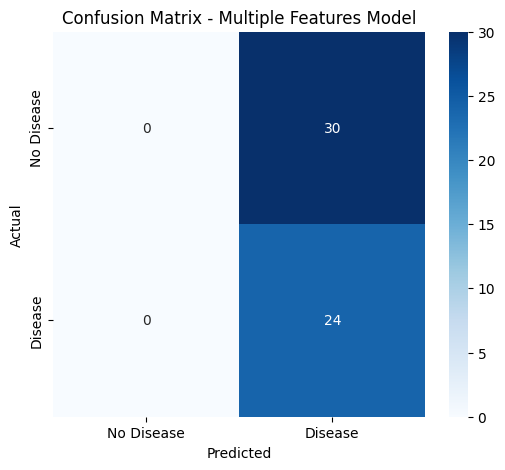

In [102]:
# Confusion matrix
cm_multi = confusion_matrix(y_full_test, y_pred_full)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Multiple Features Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model Comparison

In [108]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss'],
    'Task 1 (Cholesterol only)': [accuracy, precision, recall, f1],
    'Task 2 (All Features)':     [acc_full, prec_full, rec_full, f1_full]
})
comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

NameError: name 'prec_full' is not defined

In [ ]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
t1_vals = [accuracy, precision, recall, f1]
t2_vals = [acc_full, prec_full, rec_full, f1_full]

x = np.arange(len(metrics))
width = 0.35

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, t1_vals, width, label='Task 1 (Cholesterol)', color='steelblue')
ax.bar(x + width/2, t2_vals, width, label='Task 2 (All Features)', color='seagreen')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Task 1 vs Task 2 — Model Performance Comparison')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Discussion 

###### Task 2 does better than Task 1. This is because it uses all the features available not just cholesterol. Using features makes the model more accurate and better at finding true cases of heart disease. More features also help reduce bias. However if many features are not relevant they could make the model less reliable.

###### When we compare both models Task 1 is easy to understand because it uses one feature and one number.. It does not fit the data well. Task 2 is more complicated but much better at predicting heart disease. With many features logistic regression still helps us understand the results through its numbers.

###### The study shows that cholesterol alone is not a predictor of heart disease. It is slightly better, than guessing. This makes sense because heart disease is caused by factors working together. Task 2 uses all these factors, which's why it does better.

###### The findings also tell us that using cholesterol alone is not enough. Task 2 on the hand gives a more complete picture of heart disease. It helps doctors make decisions by using all the available information.

# Conclusion

###### This assignment showed how machine learning works for a real-world problem.

###### The problem is to classify things into two groups.

###### * Task 1 found out that using one piece of information like cholesterol level does not help much in predicting heart disease.

###### Task 1 results make sense because cholesterol is one factor.

###### * Task 2 proved that using pieces of information like age, type of chest pain and ECG results makes the model much better.

###### This is a thing because it gives more accurate results.

###### Logistic regression is good, for this kind of problem because it gives a probability and is easy to understand.

###### It also works fast.

###### The best way to measure how good the model is is to use a loss function that checks for predictions.

###### This loss function is called binary cross-entropy.

###### The model that uses features is the best one to use in real life.

###### It gives results and is easy to understand.

###### The model works well because it balances being easy to understand with giving results.